# CliffWalking: SARSA vs. Q-Learning

This notebook develops two model-free tabular control algorithms on the classic CliffWalking problem. SARSA is explained and traced first, followed by Q-Learning. The notebook then compares their learning behavior, learned policies, and final simulations.

## 1. Problem and What Will Be Learned

The agent starts at the lower-left corner of a $4\times12$ grid and must reach the goal at the lower-right corner. The cells between the start and goal form a cliff. Entering the cliff gives a large penalty and immediately returns the agent to the start.

```text
. . . . . . . . . . . .
. . . . . . . . . . . .
. . . . . . . . . . . .
S C C C C C C C C C C G
```

- `S` = start
- `G` = goal
- `C` = cliff

### State

A state is the agent's grid position:

$$s=(row,column).$$

The implementation also maps each position to an integer state ID from $0$ to $47$.

### Action

The action space is

$$\mathcal{A}=\{\text{Up},\text{Right},\text{Down},\text{Left}\}.$$

The implementation uses:

```text
0 = Up
1 = Right
2 = Down
3 = Left
```

### Transition

An action moves the agent one grid cell. If movement would leave the grid, the agent remains in the same state. If the agent enters a cliff cell, it is immediately returned to the start state.

The learning algorithms are **not given** a transition matrix $P(s'|s,a)$. They learn only from sampled experience.

### Reward

For an ordinary transition,

$$R_{t+1}=-1.$$

For entering the cliff,

$$R_{t+1}=-100.$$

The episode terminates when the goal is reached.

### What is learned?

Both algorithms learn the action-value function

$$Q^\pi(s,a)=\mathbb{E}_\pi[G_t\mid S_t=s,A_t=a],$$

where the discounted return is

$$G_t=\sum_{k=0}^{\infty}\gamma^kR_{t+k+1}.$$

For control, the goal is to approximate the optimal action-value function $Q^*(s,a)$ and derive a greedy policy

$$\pi(s)=\arg\max_a Q(s,a).$$

SARSA and Q-Learning differ mainly in the **next-state value used in the TD target**.

## 2. Imports

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

## 3. CliffWalking Environment

The environment is implemented directly so the state transitions, cliff reset, rewards, and terminal condition remain visible.

In [2]:
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3

ACTION_NAMES = {
    UP: "Up",
    RIGHT: "Right",
    DOWN: "Down",
    LEFT: "Left",
}

ACTION_SYMBOLS = {
    UP: "↑",
    RIGHT: "→",
    DOWN: "↓",
    LEFT: "←",
}


class CliffWalkingEnv:
    def __init__(self):
        self.rows = 4
        self.cols = 12
        self.start = (3, 0)
        self.goal = (3, 11)
        self.cliff = {(3, col) for col in range(1, 11)}
        self.state = self.start

    def to_id(self, state):
        row, col = state
        return row * self.cols + col

    def from_id(self, state_id):
        return divmod(int(state_id), self.cols)

    @property
    def n_states(self):
        return self.rows * self.cols

    @property
    def n_actions(self):
        return 4

    def reset(self):
        self.state = self.start
        return self.to_id(self.state)

    def step(self, action):
        row, col = self.state

        if action == UP:
            row = max(row - 1, 0)
        elif action == RIGHT:
            col = min(col + 1, self.cols - 1)
        elif action == DOWN:
            row = min(row + 1, self.rows - 1)
        elif action == LEFT:
            col = max(col - 1, 0)
        else:
            raise ValueError("Invalid action.")

        candidate = (row, col)

        if candidate in self.cliff:
            self.state = self.start
            return self.to_id(self.state), -100.0, False, {"cliff": True}

        self.state = candidate
        done = self.state == self.goal

        return self.to_id(self.state), -1.0, done, {"cliff": False}

    def render_policy(self, actions):
        rows = []

        for row in range(self.rows):
            tokens = []

            for col in range(self.cols):
                state = (row, col)

                if state == self.start:
                    tokens.append("S")
                elif state == self.goal:
                    tokens.append("G")
                elif state in self.cliff:
                    tokens.append("C")
                else:
                    state_id = self.to_id(state)
                    tokens.append(ACTION_SYMBOLS[int(actions[state_id])])

            rows.append(" ".join(tokens))

        return "\n".join(rows)

In [3]:
env = CliffWalkingEnv()

print("Number of states:", env.n_states)
print("Number of actions:", env.n_actions)
print("Start state:", env.start, "ID =", env.to_id(env.start))
print("Goal state:", env.goal, "ID =", env.to_id(env.goal))
print("Cliff cells:", sorted(env.cliff))

Number of states: 48
Number of actions: 4
Start state: (3, 0) ID = 36
Goal state: (3, 11) ID = 47
Cliff cells: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10)]


## 4. Epsilon-Greedy Action Selection

### How it works

During training, the agent must sometimes try actions that do not currently look best. An $\epsilon$-greedy policy balances exploitation and exploration. With probability $1-\epsilon$, the agent selects a greedy action with the largest current $Q$-value. With probability $\epsilon$, it selects a random action.

For a unique greedy action, this can be written as

$$\pi_\epsilon(a|s)=\begin{cases}1-\epsilon+\frac{\epsilon}{|\mathcal A|},&a=\arg\max_{a'}Q(s,a')\\\frac{\epsilon}{|\mathcal A|},&\text{otherwise}\end{cases}.$$

The implementation also handles ties by randomly selecting among actions that share the maximum $Q$-value.

In [4]:
def epsilon_greedy(q_table, state, epsilon, rng):
    if rng.random() < epsilon:
        return rng.randrange(q_table.shape[1])

    best_value = np.max(q_table[state])
    best_actions = np.flatnonzero(np.isclose(q_table[state], best_value))

    return int(rng.choice(list(best_actions)))


def epsilon_greedy_with_details(q_table, state, epsilon, rng):
    draw = rng.random()
    best_value = np.max(q_table[state])
    best_actions = np.flatnonzero(np.isclose(q_table[state], best_value))

    if draw < epsilon:
        action = rng.randrange(q_table.shape[1])
        mode = "Explore"
    else:
        action = int(rng.choice(list(best_actions)))
        mode = "Greedy"

    return action, {
        "draw": draw,
        "mode": mode,
        "best_value": float(best_value),
        "best_actions": [int(a) for a in best_actions],
    }

## Tabular Representation of the Q-Values

SARSA and Q-Learning store their action values in a **Q-table**. Each row represents one state and each column represents one possible action. For CliffWalking there are $48$ states and $4$ actions, so

$$Q\in\mathbb{R}^{48\times4}.$$

Conceptually, the table has the form

$$Q=\begin{bmatrix}Q(s_0,\text{Up})&Q(s_0,\text{Right})&Q(s_0,\text{Down})&Q(s_0,\text{Left})\\Q(s_1,\text{Up})&Q(s_1,\text{Right})&Q(s_1,\text{Down})&Q(s_1,\text{Left})\\\vdots&\vdots&\vdots&\vdots\\Q(s_{47},\text{Up})&Q(s_{47},\text{Right})&Q(s_{47},\text{Down})&Q(s_{47},\text{Left})\end{bmatrix}.$$

At initialization,

$$Q(s,a)=0\quad\text{for every }(s,a).$$

During learning, one observed transition updates **one table entry**, $Q(S_t,A_t)$, at a time. The other entries remain unchanged until they are visited and updated by later experience.

The table below shows the initial Q-values used by both algorithms.

In [5]:
from IPython.display import Markdown, display


def display_q_table(q_table, title, include_cliff=True, decimals=3):
    env = CliffWalkingEnv()

    lines = [
        f"### {title}",
        "",
        "| State ID | Position | Type | Up | Right | Down | Left |",
        "|---:|:---:|:---|---:|---:|---:|---:|",
    ]

    for state_id in range(env.n_states):
        position = env.from_id(state_id)

        if position == env.start:
            state_type = "Start"
        elif position == env.goal:
            state_type = "Goal"
        elif position in env.cliff:
            state_type = "Cliff"
        else:
            state_type = "Regular"

        if not include_cliff and state_type in {"Cliff", "Goal"}:
            continue

        values = q_table[state_id]

        lines.append(
            f"| {state_id} | {position} | {state_type} | "
            f"{values[UP]:.{decimals}f} | "
            f"{values[RIGHT]:.{decimals}f} | "
            f"{values[DOWN]:.{decimals}f} | "
            f"{values[LEFT]:.{decimals}f} |"
        )

    display(Markdown("\n".join(lines)))


initial_q_table = np.zeros((env.n_states, env.n_actions))

print("Q-table shape:", initial_q_table.shape)
print("Rows = states; columns = [Up, Right, Down, Left]")
display_q_table(
    initial_q_table,
    "Initial Q-Table",
    include_cliff=True,
    decimals=1,
)


Q-table shape: (48, 4)
Rows = states; columns = [Up, Right, Down, Left]


### Initial Q-Table

| State ID | Position | Type | Up | Right | Down | Left |
|---:|:---:|:---|---:|---:|---:|---:|
| 0 | (0, 0) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 1 | (0, 1) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 2 | (0, 2) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 3 | (0, 3) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 4 | (0, 4) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 5 | (0, 5) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 6 | (0, 6) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 7 | (0, 7) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 8 | (0, 8) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 9 | (0, 9) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 10 | (0, 10) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 11 | (0, 11) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 12 | (1, 0) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 13 | (1, 1) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 14 | (1, 2) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 15 | (1, 3) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 16 | (1, 4) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 17 | (1, 5) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 18 | (1, 6) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 19 | (1, 7) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 20 | (1, 8) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 21 | (1, 9) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 22 | (1, 10) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 23 | (1, 11) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 24 | (2, 0) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 25 | (2, 1) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 26 | (2, 2) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 27 | (2, 3) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 28 | (2, 4) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 29 | (2, 5) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 30 | (2, 6) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 31 | (2, 7) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 32 | (2, 8) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 33 | (2, 9) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 34 | (2, 10) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 35 | (2, 11) | Regular | 0.0 | 0.0 | 0.0 | 0.0 |
| 36 | (3, 0) | Start | 0.0 | 0.0 | 0.0 | 0.0 |
| 37 | (3, 1) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 38 | (3, 2) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 39 | (3, 3) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 40 | (3, 4) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 41 | (3, 5) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 42 | (3, 6) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 43 | (3, 7) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 44 | (3, 8) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 45 | (3, 9) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 46 | (3, 10) | Cliff | 0.0 | 0.0 | 0.0 | 0.0 |
| 47 | (3, 11) | Goal | 0.0 | 0.0 | 0.0 | 0.0 |

# 5. SARSA

## How SARSA Works

SARSA is an **on-policy Temporal-Difference control** algorithm. At state $S_t$, the agent selects action $A_t$ using the current $\epsilon$-greedy behavior policy. After executing the action, it observes reward $R_{t+1}$ and next state $S_{t+1}$. Before updating, it also selects the actual next behavior action $A_{t+1}$ using the same $\epsilon$-greedy policy. The value of $(S_t,A_t)$ is then moved toward a target containing $Q(S_{t+1},A_{t+1})$. Because the update uses the action that the behavior policy actually chooses next, SARSA is on-policy.

The one-step SARSA target is

$$Y_t^{SARSA}=R_{t+1}+\gamma Q(S_{t+1},A_{t+1}).$$

For a terminal transition,

$$Y_t^{SARSA}=R_{t+1}.$$

The TD error is

$$\delta_t=Y_t^{SARSA}-Q(S_t,A_t).$$

The update is

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\delta_t.$$

Equivalently,

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)\right].$$

## SARSA Algorithm

```text
Input:
    learning rate α
    discount factor γ
    exploration rate ε
    number of episodes

Initialize:
    Q(s,a) = 0 for every state-action pair

For each episode:

    1. Reset the environment

       observe initial state S

    2. Select the initial action using ε-greedy

       A = ε-greedy(Q, S)

    3. Repeat until the goal is reached:

       a. Execute action A

       b. Observe:
              reward R
              next state S'
              terminal flag done

       c. If the transition is terminal:

              target = R

              TD_error = target - Q(S,A)

              update = α × TD_error

              Q(S,A) = Q(S,A) + update

              stop this episode

       d. Otherwise select the actual next behavior action:

              A' = ε-greedy(Q, S')

       e. Read the bootstrap value:

              next_Q = Q(S',A')

       f. Compute the SARSA target:

              target = R + γ × next_Q

       g. Compute the TD error:

              TD_error = target - Q(S,A)

       h. Compute the update amount:

              update = α × TD_error

       i. Update the current state-action value:

              Q(S,A) = Q(S,A) + update

       j. Move to the next decision:

              S = S'
              A = A'

    4. Continue with the next episode

Output:
    learned Q(s,a)
    greedy policy π(s) = argmax_a Q(s,a)
```

The complete SARSA flow is therefore:

```text
S_t
 ↓
choose A_t with ε-greedy
 ↓
execute A_t
 ↓
observe R_t+1 and S_t+1
 ↓
choose actual A_t+1 with ε-greedy
 ↓
read Q(S_t+1,A_t+1)
 ↓
compute target
 ↓
compute TD error
 ↓
update Q(S_t,A_t)
 ↓
continue with S_t+1, A_t+1
```

## 6. SARSA Implementation

The function below follows the algorithm exactly and stores episode return, episode length, and the number of cliff falls for later analysis.

In [6]:
def train_sarsa(
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=0,
    max_steps=1000,
):
    env = CliffWalkingEnv()
    rng = random.Random(seed)

    Q = np.zeros((env.n_states, env.n_actions), dtype=float)

    returns = []
    lengths = []
    cliff_falls = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon, rng)

        total_reward = 0.0
        falls = 0

        for step in range(1, max_steps + 1):
            next_state, reward, done, info = env.step(action)

            total_reward += reward
            falls += int(info["cliff"])

            if done:
                target = reward
                td_error = target - Q[state, action]
                Q[state, action] += alpha * td_error
                break

            next_action = epsilon_greedy(Q, next_state, epsilon, rng)
            target = reward + gamma * Q[next_state, next_action]
            td_error = target - Q[state, action]
            Q[state, action] += alpha * td_error

            state = next_state
            action = next_action

        returns.append(total_reward)
        lengths.append(step)
        cliff_falls.append(falls)

    return {
        "Q": Q,
        "returns": np.asarray(returns),
        "lengths": np.asarray(lengths),
        "cliff_falls": np.asarray(cliff_falls),
    }

## 7. Code-Generated SARSA Update

For one sampled non-terminal transition, the notebook prints every value used in

$$Y_t^{SARSA}=R_{t+1}+\gamma Q(S_{t+1},A_{t+1}),$$

$$\delta_t=Y_t^{SARSA}-Q(S_t,A_t),$$

and

$$Q_{\text{new}}(S_t,A_t)=Q_{\text{old}}(S_t,A_t)+\alpha\delta_t.$$

In [7]:
warm_sarsa = train_sarsa(
    episodes=80,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=10,
)

Q_demo = warm_sarsa["Q"].copy()
demo_env = CliffWalkingEnv()
demo_rng = random.Random(19)

state = demo_env.reset()

for _ in range(100):
    action, action_info = epsilon_greedy_with_details(
        Q_demo, state, 0.1, demo_rng
    )

    next_state, reward, done, info = demo_env.step(action)

    if not done and not info["cliff"]:
        break

    state = demo_env.reset()

next_action, next_action_info = epsilon_greedy_with_details(
    Q_demo, next_state, 0.1, demo_rng
)

alpha_demo = 0.5
gamma_demo = 1.0

old_q = Q_demo[state, action]
next_q = Q_demo[next_state, next_action]
target = reward + gamma_demo * next_q
td_error = target - old_q
update = alpha_demo * td_error
new_q = old_q + update

print("Observed transition")
print("  S_t                    =", state, demo_env.from_id(state))
print("  Q(S_t, all actions)    =", np.round(Q_demo[state], 4))
print("  ε-greedy draw          =", round(action_info["draw"], 4))
print("  Selection mode         =", action_info["mode"])
print("  A_t                    =", ACTION_NAMES[action])
print("  R_t+1                  =", reward)
print("  S_t+1                  =", next_state, demo_env.from_id(next_state))
print("  Q(S_t+1, all actions)  =", np.round(Q_demo[next_state], 4))
print("  Next ε-greedy draw     =", round(next_action_info["draw"], 4))
print("  Next selection mode    =", next_action_info["mode"])
print("  A_t+1                  =", ACTION_NAMES[next_action])
print()
print("SARSA target")
print(f"  target = R_t+1 + γQ(S_t+1,A_t+1)")
print(f"         = {reward} + {gamma_demo} × {next_q}")
print(f"         = {target}")
print()
print("TD error")
print(f"  δ_t = target - Q(S_t,A_t)")
print(f"      = {target} - {old_q}")
print(f"      = {td_error}")
print()
print("Q update")
print(f"  update = α × δ_t")
print(f"         = {alpha_demo} × {td_error}")
print(f"         = {update}")
print(f"  Q_new  = {old_q} + {update}")
print(f"         = {new_q}")

Observed transition
  S_t                    = 36 (3, 0)
  Q(S_t, all actions)    = [ -19.121  -106.3184  -24.0075  -22.844 ]
  ε-greedy draw          = 0.6771
  Selection mode         = Greedy
  A_t                    = Up
  R_t+1                  = -1.0
  S_t+1                  = 24 (2, 0)
  Q(S_t+1, all actions)  = [-17.9045 -19.8876 -25.9732 -20.0213]
  Next ε-greedy draw     = 0.5115
  Next selection mode    = Greedy
  A_t+1                  = Up

SARSA target
  target = R_t+1 + γQ(S_t+1,A_t+1)
         = -1.0 + 1.0 × -17.904490295006674
         = -18.904490295006674

TD error
  δ_t = target - Q(S_t,A_t)
      = -18.904490295006674 - -19.12103459805487
      = 0.21654430304819527

Q update
  update = α × δ_t
         = 0.5 × 0.21654430304819527
         = 0.10827215152409764
  Q_new  = -19.12103459805487 + 0.10827215152409764
         = -19.012762446530772


## 8. SARSA: Print 60 Consecutive Learning Updates

A single CliffWalking episode may finish before 60 transitions. To make the learning process fully visible, the trace below continues across consecutive episodes until **60 SARSA updates** have been printed.

For every update it prints:

- episode and step number,
- current state and all current-state $Q$-values,
- $\epsilon$-greedy random draw and whether the action was exploratory or greedy,
- selected $A_t$,
- reward and next state,
- next-state $Q$-values,
- actual next behavior action $A_{t+1}$,
- bootstrap value,
- SARSA target,
- TD error,
- update amount,
- new $Q(S_t,A_t)$,
- cliff and terminal flags.

In [8]:
def trace_sarsa_updates(
    Q_start,
    total_updates=60,
    seed=11,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
):
    Q = Q_start.copy()
    env = CliffWalkingEnv()
    rng = random.Random(seed)

    update_number = 0
    episode_number = 1
    episode_step = 1

    state = env.reset()
    action, action_info = epsilon_greedy_with_details(
        Q, state, epsilon, rng
    )

    while update_number < total_updates:
        current_q_values = Q[state].copy()

        next_state, reward, done, info = env.step(action)

        old_q = Q[state, action]

        if done:
            next_action = None
            next_action_info = None
            next_q_values = np.zeros(env.n_actions)
            next_q = 0.0
            target = reward
        else:
            next_q_values = Q[next_state].copy()
            next_action, next_action_info = epsilon_greedy_with_details(
                Q, next_state, epsilon, rng
            )
            next_q = Q[next_state, next_action]
            target = reward + gamma * next_q

        td_error = target - old_q
        update = alpha * td_error
        new_q = old_q + update
        Q[state, action] = new_q

        update_number += 1

        print(
            f"Update {update_number} | "
            f"Episode {episode_number} | "
            f"Episode step {episode_step}"
        )
        print("  S_t                    =", state, env.from_id(state))
        print("  Q(S_t, all actions)    =", np.round(current_q_values, 4))
        print("  ε                      =", epsilon)
        print("  ε-greedy draw          =", round(action_info["draw"], 4))
        print("  Selection mode         =", action_info["mode"])
        print("  Greedy action IDs      =", action_info["best_actions"])
        print("  A_t                    =", ACTION_NAMES[action])
        print("  R_t+1                  =", reward)
        print("  S_t+1                  =", next_state, env.from_id(next_state))
        print("  Cliff fall?            =", info["cliff"])
        print("  Terminal?              =", done)

        if done:
            print("  Q(S_t+1, all actions)  = terminal -> [0, 0, 0, 0]")
            print("  A_t+1                  = None")
            print("  Bootstrap Q            = 0.0")
        else:
            print("  Q(S_t+1, all actions)  =", np.round(next_q_values, 4))
            print("  Next ε-greedy draw     =", round(next_action_info["draw"], 4))
            print("  Next selection mode    =", next_action_info["mode"])
            print("  A_t+1                  =", ACTION_NAMES[next_action])
            print("  Bootstrap Q            =", next_q)

        print("  Q(S_t,A_t) before      =", old_q)
        print("  Target                 =", target)
        print("  TD error               =", td_error)
        print("  α × TD error           =", update)
        print("  Q(S_t,A_t) after       =", new_q)
        print()

        if done:
            episode_number += 1
            episode_step = 1
            state = env.reset()
            action, action_info = epsilon_greedy_with_details(
                Q, state, epsilon, rng
            )
        else:
            state = next_state
            action = next_action
            action_info = next_action_info
            episode_step += 1

    print("Total SARSA updates printed =", update_number)

    return Q


trace_start_sarsa = train_sarsa(
    episodes=1500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=2026,
)["Q"]

_ = trace_sarsa_updates(
    trace_start_sarsa,
    total_updates=60,
    seed=11,
)

Update 1 | Episode 1 | Episode step 1
  S_t                    = 36 (3, 0)
  Q(S_t, all actions)    = [ -19.4204 -120.4672  -21.1647  -22.2357]
  ε                      = 0.1
  ε-greedy draw          = 0.4524
  Selection mode         = Greedy
  Greedy action IDs      = [0]
  A_t                    = Up
  R_t+1                  = -1.0
  S_t+1                  = 24 (2, 0)
  Cliff fall?            = False
  Terminal?              = False
  Q(S_t+1, all actions)  = [-17.9486 -22.2084 -24.079  -20.4013]
  Next ε-greedy draw     = 0.4518
  Next selection mode    = Greedy
  A_t+1                  = Up
  Bootstrap Q            = -17.948619210968126
  Q(S_t,A_t) before      = -19.4204060090144
  Target                 = -18.948619210968126
  TD error               = 0.4717867980462742
  α × TD error           = 0.2358933990231371
  Q(S_t,A_t) after       = -19.184512609991263

Update 2 | Episode 1 | Episode step 2
  S_t                    = 24 (2, 0)
  Q(S_t, all actions)    = [-17.9486 -22.208

# 9. Q-Learning

## How Q-Learning Works

Q-Learning is an **off-policy Temporal-Difference control** algorithm. The agent still uses an $\epsilon$-greedy behavior policy to generate experience, but the update does not use the actual exploratory action selected next. Instead, after reaching $S_{t+1}$, Q-Learning looks at **all** action values in that next state and uses the largest one in the target. It therefore learns toward the greedy target policy while the behavior policy continues to explore.

The one-step Q-Learning target is

$$Y_t^{Q}=R_{t+1}+\gamma\max_aQ(S_{t+1},a).$$

For a terminal transition,

$$Y_t^{Q}=R_{t+1}.$$

The TD error is

$$\delta_t=Y_t^{Q}-Q(S_t,A_t).$$

The update is

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\delta_t.$$

Equivalently,

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[R_{t+1}+\gamma\max_aQ(S_{t+1},a)-Q(S_t,A_t)\right].$$

## Q-Learning Algorithm

```text
Input:
    learning rate α
    discount factor γ
    exploration rate ε
    number of episodes

Initialize:
    Q(s,a) = 0 for every state-action pair

For each episode:

    1. Reset the environment

       observe initial state S

    2. Repeat until the goal is reached:

       a. Select a behavior action with ε-greedy

              A = ε-greedy(Q, S)

       b. Execute A

       c. Observe:
              reward R
              next state S'
              terminal flag done

       d. If the transition is terminal:

              target = R

       e. Otherwise evaluate every next-state action

              Q(S', Up)
              Q(S', Right)
              Q(S', Down)
              Q(S', Left)

          and select the largest value:

              best_next_Q = max_a Q(S',a)

          form the target:

              target = R + γ × best_next_Q

       f. Compute the TD error:

              TD_error = target - Q(S,A)

       g. Compute the update amount:

              update = α × TD_error

       h. Update the current state-action value:

              Q(S,A) = Q(S,A) + update

       i. If done:

              stop this episode

          otherwise:

              S = S'

    3. Continue with the next episode

Output:
    learned Q(s,a)
    greedy policy π(s) = argmax_a Q(s,a)
```

The complete Q-Learning flow is:

```text
S_t
 ↓
choose behavior A_t with ε-greedy
 ↓
execute A_t
 ↓
observe R_t+1 and S_t+1
 ↓
inspect every Q(S_t+1,a)
 ↓
take max_a Q(S_t+1,a)
 ↓
compute target
 ↓
compute TD error
 ↓
update Q(S_t,A_t)
 ↓
continue from S_t+1
```

## 10. Q-Learning Implementation

The implementation follows the off-policy target above and stores the same training statistics as SARSA so the comparison is controlled.

In [9]:
def train_q_learning(
    episodes=500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=0,
    max_steps=1000,
):
    env = CliffWalkingEnv()
    rng = random.Random(seed)

    Q = np.zeros((env.n_states, env.n_actions), dtype=float)

    returns = []
    lengths = []
    cliff_falls = []

    for episode in range(episodes):
        state = env.reset()

        total_reward = 0.0
        falls = 0

        for step in range(1, max_steps + 1):
            action = epsilon_greedy(Q, state, epsilon, rng)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            falls += int(info["cliff"])

            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q[next_state])

            td_error = target - Q[state, action]
            Q[state, action] += alpha * td_error

            if done:
                break

            state = next_state

        returns.append(total_reward)
        lengths.append(step)
        cliff_falls.append(falls)

    return {
        "Q": Q,
        "returns": np.asarray(returns),
        "lengths": np.asarray(lengths),
        "cliff_falls": np.asarray(cliff_falls),
    }

## 11. Code-Generated Q-Learning Update

For one sampled transition, the notebook prints all next-state action values so the maximum used by Q-Learning can be seen directly.

$$Y_t^{Q}=R_{t+1}+\gamma\max_aQ(S_{t+1},a)$$

$$\delta_t=Y_t^{Q}-Q(S_t,A_t)$$

$$Q_{\text{new}}(S_t,A_t)=Q_{\text{old}}(S_t,A_t)+\alpha\delta_t$$

In [10]:
warm_q = train_q_learning(
    episodes=80,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=10,
)

Q_demo_q = warm_q["Q"].copy()
demo_env_q = CliffWalkingEnv()
demo_rng_q = random.Random(19)

state_q = demo_env_q.reset()

for _ in range(100):
    action_q, action_info_q = epsilon_greedy_with_details(
        Q_demo_q, state_q, 0.1, demo_rng_q
    )

    next_state_q, reward_q, done_q, info_q = demo_env_q.step(action_q)

    if not done_q and not info_q["cliff"]:
        break

    state_q = demo_env_q.reset()

alpha_demo_q = 0.5
gamma_demo_q = 1.0

old_q_value = Q_demo_q[state_q, action_q]
next_values_q = Q_demo_q[next_state_q].copy()
best_next_action = int(np.argmax(next_values_q))
best_next_value = float(np.max(next_values_q))

target_q = reward_q + gamma_demo_q * best_next_value
td_error_q = target_q - old_q_value
update_q = alpha_demo_q * td_error_q
new_q_value = old_q_value + update_q

print("Observed transition")
print("  S_t                    =", state_q, demo_env_q.from_id(state_q))
print("  Q(S_t, all actions)    =", np.round(Q_demo_q[state_q], 4))
print("  ε-greedy draw          =", round(action_info_q["draw"], 4))
print("  Selection mode         =", action_info_q["mode"])
print("  A_t                    =", ACTION_NAMES[action_q])
print("  R_t+1                  =", reward_q)
print("  S_t+1                  =", next_state_q, demo_env_q.from_id(next_state_q))
print()
print("All Q(S_t+1,a) values")
for action_index in range(4):
    print(f"  {ACTION_NAMES[action_index]:>5} =", next_values_q[action_index])
print("  Greedy next action     =", ACTION_NAMES[best_next_action])
print("  max_a Q(S_t+1,a)       =", best_next_value)
print()
print("Q-Learning target")
print(f"  target = R_t+1 + γ max_a Q(S_t+1,a)")
print(f"         = {reward_q} + {gamma_demo_q} × {best_next_value}")
print(f"         = {target_q}")
print()
print("TD error")
print(f"  δ_t = target - Q(S_t,A_t)")
print(f"      = {target_q} - {old_q_value}")
print(f"      = {td_error_q}")
print()
print("Q update")
print(f"  update = α × δ_t")
print(f"         = {alpha_demo_q} × {td_error_q}")
print(f"         = {update_q}")
print(f"  Q_new  = {old_q_value} + {update_q}")
print(f"         = {new_q_value}")

Observed transition
  S_t                    = 36 (3, 0)
  Q(S_t, all actions)    = [ -13.     -106.6857  -13.2192  -13.7694]
  ε-greedy draw          = 0.6771
  Selection mode         = Greedy
  A_t                    = Up
  R_t+1                  = -1.0
  S_t+1                  = 24 (2, 0)

All Q(S_t+1,a) values
     Up = -12.002603735592484
  Right = -11.999999999687741
   Down = -12.622425667758769
   Left = -12.732243425617895
  Greedy next action     = Right
  max_a Q(S_t+1,a)       = -11.999999999687741

Q-Learning target
  target = R_t+1 + γ max_a Q(S_t+1,a)
         = -1.0 + 1.0 × -11.999999999687741
         = -12.999999999687741

TD error
  δ_t = target - Q(S_t,A_t)
      = -12.999999999687741 - -12.999999999213031
      = -4.747100490476441e-10

Q update
  update = α × δ_t
         = 0.5 × -4.747100490476441e-10
         = -2.3735502452382207e-10
  Q_new  = -12.999999999213031 + -2.3735502452382207e-10
         = -12.999999999450386


## 12. Q-Learning: Print 60 Consecutive Learning Updates

The following trace continues across episodes until **60 Q-Learning updates** are printed. At every update, all four next-state action values are displayed before taking the maximum. This makes the off-policy target visible numerically at every step.

In [11]:
def trace_q_learning_updates(
    Q_start,
    total_updates=60,
    seed=11,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
):
    Q = Q_start.copy()
    env = CliffWalkingEnv()
    rng = random.Random(seed)

    update_number = 0
    episode_number = 1
    episode_step = 1

    state = env.reset()

    while update_number < total_updates:
        current_q_values = Q[state].copy()

        action, action_info = epsilon_greedy_with_details(
            Q, state, epsilon, rng
        )

        next_state, reward, done, info = env.step(action)

        old_q = Q[state, action]

        if done:
            next_values = np.zeros(env.n_actions)
            best_next_action = None
            best_next = 0.0
            target = reward
        else:
            next_values = Q[next_state].copy()
            best_next_action = int(np.argmax(next_values))
            best_next = float(np.max(next_values))
            target = reward + gamma * best_next

        td_error = target - old_q
        update = alpha * td_error
        new_q = old_q + update
        Q[state, action] = new_q

        update_number += 1

        print(
            f"Update {update_number} | "
            f"Episode {episode_number} | "
            f"Episode step {episode_step}"
        )
        print("  S_t                    =", state, env.from_id(state))
        print("  Q(S_t, all actions)    =", np.round(current_q_values, 4))
        print("  ε                      =", epsilon)
        print("  ε-greedy draw          =", round(action_info["draw"], 4))
        print("  Selection mode         =", action_info["mode"])
        print("  Greedy action IDs      =", action_info["best_actions"])
        print("  A_t                    =", ACTION_NAMES[action])
        print("  R_t+1                  =", reward)
        print("  S_t+1                  =", next_state, env.from_id(next_state))
        print("  Cliff fall?            =", info["cliff"])
        print("  Terminal?              =", done)

        if done:
            print("  Q(S_t+1, all actions)  = terminal -> [0, 0, 0, 0]")
            print("  Greedy next action     = None")
            print("  max next Q             = 0.0")
        else:
            print("  Q(S_t+1, all actions)  =", np.round(next_values, 4))
            print("  Greedy next action     =", ACTION_NAMES[best_next_action])
            print("  max next Q             =", best_next)

        print("  Q(S_t,A_t) before      =", old_q)
        print("  Target                 =", target)
        print("  TD error               =", td_error)
        print("  α × TD error           =", update)
        print("  Q(S_t,A_t) after       =", new_q)
        print()

        if done:
            episode_number += 1
            episode_step = 1
            state = env.reset()
        else:
            state = next_state
            episode_step += 1

    print("Total Q-Learning updates printed =", update_number)

    return Q


trace_start_q = train_q_learning(
    episodes=1500,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=2026,
)["Q"]

_ = trace_q_learning_updates(
    trace_start_q,
    total_updates=60,
    seed=11,
)

Update 1 | Episode 1 | Episode step 1
  S_t                    = 36 (3, 0)
  Q(S_t, all actions)    = [ -13. -113.  -14.  -14.]
  ε                      = 0.1
  ε-greedy draw          = 0.4524
  Selection mode         = Greedy
  Greedy action IDs      = [0]
  A_t                    = Up
  R_t+1                  = -1.0
  S_t+1                  = 24 (2, 0)
  Cliff fall?            = False
  Terminal?              = False
  Q(S_t+1, all actions)  = [-14. -12. -14. -13.]
  Greedy next action     = Right
  max next Q             = -12.0
  Q(S_t,A_t) before      = -13.0
  Target                 = -13.0
  TD error               = 0.0
  α × TD error           = 0.0
  Q(S_t,A_t) after       = -13.0

Update 2 | Episode 1 | Episode step 2
  S_t                    = 24 (2, 0)
  Q(S_t, all actions)    = [-14. -12. -14. -13.]
  ε                      = 0.1
  ε-greedy draw          = 0.4518
  Selection mode         = Greedy
  Greedy action IDs      = [1]
  A_t                    = Right
  R_t+1      

## 13. Controlled Training Comparison

Both methods are now trained under the same settings:

- $500$ episodes,
- $\alpha=0.5$,
- $\gamma=1.0$,
- $\epsilon=0.1$,
- the same set of $20$ random seeds.

Using multiple seeds reduces the chance that the comparison is dominated by one random training run.

In [12]:
episodes = 500
seeds = list(range(20))

sarsa_runs = []
q_runs = []

for seed in seeds:
    sarsa_runs.append(
        train_sarsa(
            episodes=episodes,
            alpha=0.5,
            gamma=1.0,
            epsilon=0.1,
            seed=seed,
        )
    )

    q_runs.append(
        train_q_learning(
            episodes=episodes,
            alpha=0.5,
            gamma=1.0,
            epsilon=0.1,
            seed=seed,
        )
    )

sarsa_returns = np.vstack([run["returns"] for run in sarsa_runs])
q_returns = np.vstack([run["returns"] for run in q_runs])

sarsa_falls = np.vstack([run["cliff_falls"] for run in sarsa_runs])
q_falls = np.vstack([run["cliff_falls"] for run in q_runs])

print("Completed seeds:", len(seeds))
print("Episodes per seed:", episodes)

Completed seeds: 20
Episodes per seed: 500


## 14. Average Episode Return

The episode return is

$$G_0=\sum_{t=0}^{T-1}R_{t+1}.$$

Because $\gamma=1$ in this experiment, every step penalty and cliff penalty contributes directly to the episode return. Higher return therefore means a less costly trajectory.

A moving average is used to make the training trend easier to see:

$$\overline{G}_n=\frac{1}{w}\sum_{i=n-w+1}^{n}G_i.$$

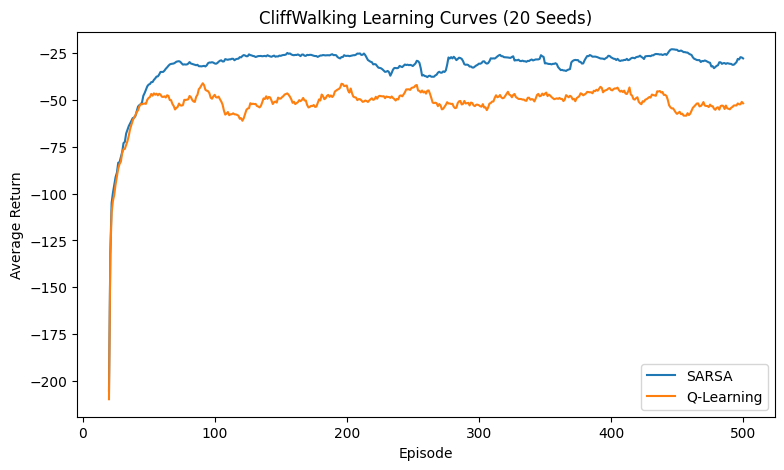

In [13]:
def moving_average(values, window=20):
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


sarsa_mean_return = np.mean(sarsa_returns, axis=0)
q_mean_return = np.mean(q_returns, axis=0)

window = 20

plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(window, episodes + 1),
    moving_average(sarsa_mean_return, window),
    label="SARSA",
)
plt.plot(
    np.arange(window, episodes + 1),
    moving_average(q_mean_return, window),
    label="Q-Learning",
)
plt.xlabel("Episode")
plt.ylabel("Average Return")
plt.title(f"CliffWalking Learning Curves ({len(seeds)} Seeds)")
plt.legend()
plt.show()

## 15. Cliff Falls During Learning

The second training graph measures how often the exploratory behavior enters the cliff. This is important because SARSA learns using the actual behavior action, while Q-Learning learns toward a greedy target even when the behavior continues to explore.

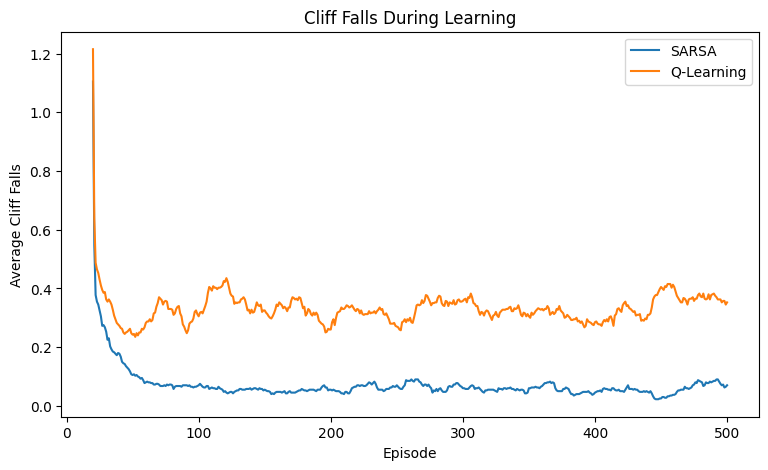

In [14]:
sarsa_mean_falls = np.mean(sarsa_falls, axis=0)
q_mean_falls = np.mean(q_falls, axis=0)

plt.figure(figsize=(9, 5))
plt.plot(
    np.arange(window, episodes + 1),
    moving_average(sarsa_mean_falls, window),
    label="SARSA",
)
plt.plot(
    np.arange(window, episodes + 1),
    moving_average(q_mean_falls, window),
    label="Q-Learning",
)
plt.xlabel("Episode")
plt.ylabel("Average Cliff Falls")
plt.title("Cliff Falls During Learning")
plt.legend()
plt.show()

## 16. Train Final Policies

Longer $5000$-episode runs are used to inspect representative learned policies. After training, the greedy action in each state is

$$\pi(s)=\arg\max_aQ(s,a).$$

In [15]:
final_sarsa = train_sarsa(
    episodes=5000,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=2026,
)

final_q = train_q_learning(
    episodes=5000,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=2026,
)

sarsa_policy = np.argmax(final_sarsa["Q"], axis=1)
q_policy = np.argmax(final_q["Q"], axis=1)

env = CliffWalkingEnv()

print("SARSA greedy policy:")
print(env.render_policy(sarsa_policy))

print("\nQ-Learning greedy policy:")
print(env.render_policy(q_policy))

SARSA greedy policy:
→ → → → → → → → → → → ↓
↑ ↑ ↑ ↑ → ↑ ↑ ↑ ↑ ↑ → ↓
↑ ← ↑ ↑ → ↑ ↑ ↑ ↑ ↑ → ↓
S C C C C C C C C C C G

Q-Learning greedy policy:
↓ ↓ → → → ↓ → → → ↓ ↓ ↓
→ → → → → → → → → → → ↓
→ → → → → → → → → → → ↓
S C C C C C C C C C C G


## Learned Q-Value Tables

After training, each row contains the learned values of the four actions available from that state. The greedy action is the column with the largest value:

$$\pi(s)=\arg\max_aQ(s,a).$$

The cliff cells and goal are omitted below because they are not ordinary decision states in this implementation. Entering a cliff immediately resets the agent to the start, and the goal terminates the episode.

Showing the learned tables makes the tabular nature of SARSA and Q-Learning explicit: the policy is obtained directly from these stored state-action values.

In [16]:
display_q_table(
    final_sarsa["Q"],
    "Learned SARSA Q-Table",
    include_cliff=False,
    decimals=3,
)

display_q_table(
    final_q["Q"],
    "Learned Q-Learning Q-Table",
    include_cliff=False,
    decimals=3,
)


### Learned SARSA Q-Table

| State ID | Position | Type | Up | Right | Down | Left |
|---:|:---:|:---|---:|---:|---:|---:|
| 0 | (0, 0) | Regular | -22.590 | -17.376 | -22.519 | -19.654 |
| 1 | (0, 1) | Regular | -22.259 | -15.240 | -49.776 | -22.970 |
| 2 | (0, 2) | Regular | -16.874 | -13.351 | -20.257 | -21.045 |
| 3 | (0, 3) | Regular | -18.875 | -12.482 | -19.125 | -21.266 |
| 4 | (0, 4) | Regular | -17.507 | -12.393 | -17.646 | -16.910 |
| 5 | (0, 5) | Regular | -16.719 | -12.325 | -20.083 | -16.670 |
| 6 | (0, 6) | Regular | -13.504 | -12.162 | -15.226 | -16.677 |
| 7 | (0, 7) | Regular | -10.908 | -9.948 | -13.434 | -13.859 |
| 8 | (0, 8) | Regular | -9.962 | -8.064 | -12.066 | -12.729 |
| 9 | (0, 9) | Regular | -10.012 | -6.746 | -9.561 | -11.268 |
| 10 | (0, 10) | Regular | -9.116 | -4.268 | -17.223 | -8.806 |
| 11 | (0, 11) | Regular | -7.948 | -9.087 | -3.034 | -15.209 |
| 12 | (1, 0) | Regular | -18.370 | -21.113 | -25.050 | -21.353 |
| 13 | (1, 1) | Regular | -20.938 | -28.704 | -49.292 | -25.408 |
| 14 | (1, 2) | Regular | -18.202 | -27.533 | -26.492 | -24.275 |
| 15 | (1, 3) | Regular | -15.133 | -21.929 | -34.049 | -24.672 |
| 16 | (1, 4) | Regular | -26.629 | -15.577 | -26.199 | -24.464 |
| 17 | (1, 5) | Regular | -18.102 | -21.431 | -29.488 | -21.865 |
| 18 | (1, 6) | Regular | -12.201 | -25.861 | -26.051 | -25.975 |
| 19 | (1, 7) | Regular | -9.211 | -23.805 | -20.599 | -25.758 |
| 20 | (1, 8) | Regular | -8.546 | -16.489 | -23.384 | -18.074 |
| 21 | (1, 9) | Regular | -8.244 | -20.372 | -28.138 | -15.126 |
| 22 | (1, 10) | Regular | -7.915 | -3.059 | -7.330 | -9.398 |
| 23 | (1, 11) | Regular | -6.766 | -4.053 | -2.000 | -6.603 |
| 24 | (2, 0) | Regular | -19.212 | -24.345 | -26.259 | -25.243 |
| 25 | (2, 1) | Regular | -25.301 | -33.276 | -123.625 | -22.091 |
| 26 | (2, 2) | Regular | -20.847 | -61.223 | -127.308 | -27.515 |
| 27 | (2, 3) | Regular | -19.481 | -42.384 | -123.204 | -51.635 |
| 28 | (2, 4) | Regular | -26.107 | -24.874 | -113.820 | -28.109 |
| 29 | (2, 5) | Regular | -19.893 | -25.087 | -89.209 | -29.455 |
| 30 | (2, 6) | Regular | -26.224 | -46.612 | -124.290 | -29.525 |
| 31 | (2, 7) | Regular | -13.934 | -68.712 | -112.135 | -71.484 |
| 32 | (2, 8) | Regular | -15.106 | -42.756 | -121.781 | -22.052 |
| 33 | (2, 9) | Regular | -9.425 | -34.118 | -123.661 | -18.983 |
| 34 | (2, 10) | Regular | -6.776 | -2.000 | -123.400 | -12.466 |
| 35 | (2, 11) | Regular | -4.708 | -2.208 | -1.000 | -3.686 |
| 36 | (3, 0) | Start | -20.304 | -123.224 | -24.006 | -27.266 |

### Learned Q-Learning Q-Table

| State ID | Position | Type | Up | Right | Down | Left |
|---:|:---:|:---|---:|---:|---:|---:|
| 0 | (0, 0) | Regular | -13.760 | -13.529 | -13.517 | -13.597 |
| 1 | (0, 1) | Regular | -12.914 | -12.835 | -12.727 | -13.396 |
| 2 | (0, 2) | Regular | -12.258 | -11.958 | -11.977 | -12.172 |
| 3 | (0, 3) | Regular | -11.464 | -10.982 | -10.991 | -11.230 |
| 4 | (0, 4) | Regular | -10.364 | -9.992 | -9.995 | -10.599 |
| 5 | (0, 5) | Regular | -9.647 | -8.996 | -8.995 | -10.387 |
| 6 | (0, 6) | Regular | -8.481 | -7.998 | -7.998 | -8.441 |
| 7 | (0, 7) | Regular | -7.695 | -6.999 | -6.999 | -8.455 |
| 8 | (0, 8) | Regular | -6.158 | -6.000 | -6.000 | -7.382 |
| 9 | (0, 9) | Regular | -5.469 | -5.000 | -5.000 | -6.560 |
| 10 | (0, 10) | Regular | -4.500 | -4.000 | -4.000 | -4.370 |
| 11 | (0, 11) | Regular | -3.500 | -3.500 | -3.000 | -4.043 |
| 12 | (1, 0) | Regular | -13.957 | -13.000 | -13.000 | -13.984 |
| 13 | (1, 1) | Regular | -13.269 | -12.000 | -12.000 | -13.944 |
| 14 | (1, 2) | Regular | -12.861 | -11.000 | -11.000 | -12.997 |
| 15 | (1, 3) | Regular | -11.948 | -10.000 | -10.000 | -11.996 |
| 16 | (1, 4) | Regular | -10.943 | -9.000 | -9.000 | -10.947 |
| 17 | (1, 5) | Regular | -9.935 | -8.000 | -8.000 | -9.998 |
| 18 | (1, 6) | Regular | -8.966 | -7.000 | -7.000 | -8.972 |
| 19 | (1, 7) | Regular | -7.993 | -6.000 | -6.000 | -7.995 |
| 20 | (1, 8) | Regular | -6.910 | -5.000 | -5.000 | -6.991 |
| 21 | (1, 9) | Regular | -5.986 | -4.000 | -4.000 | -6.000 |
| 22 | (1, 10) | Regular | -5.000 | -3.000 | -3.000 | -4.996 |
| 23 | (1, 11) | Regular | -3.942 | -2.875 | -2.000 | -3.975 |
| 24 | (2, 0) | Regular | -14.000 | -12.000 | -14.000 | -13.000 |
| 25 | (2, 1) | Regular | -13.000 | -11.000 | -113.000 | -13.000 |
| 26 | (2, 2) | Regular | -12.000 | -10.000 | -113.000 | -12.000 |
| 27 | (2, 3) | Regular | -11.000 | -9.000 | -113.000 | -11.000 |
| 28 | (2, 4) | Regular | -10.000 | -8.000 | -113.000 | -10.000 |
| 29 | (2, 5) | Regular | -9.000 | -7.000 | -113.000 | -9.000 |
| 30 | (2, 6) | Regular | -8.000 | -6.000 | -113.000 | -8.000 |
| 31 | (2, 7) | Regular | -7.000 | -5.000 | -113.000 | -7.000 |
| 32 | (2, 8) | Regular | -6.000 | -4.000 | -113.000 | -6.000 |
| 33 | (2, 9) | Regular | -5.000 | -3.000 | -113.000 | -5.000 |
| 34 | (2, 10) | Regular | -4.000 | -2.000 | -113.000 | -4.000 |
| 35 | (2, 11) | Regular | -3.000 | -2.000 | -1.000 | -3.000 |
| 36 | (3, 0) | Start | -13.000 | -113.000 | -14.000 | -14.000 |

## 17. Greedy Paths Learned by the Two Algorithms

The following code executes each learned greedy policy without exploration and records the full path, total reward, number of cliff falls, and whether the goal is reached.

In [17]:
def greedy_path(q_table, max_steps=100):
    env = CliffWalkingEnv()
    state = env.reset()

    path = [env.from_id(state)]
    total_reward = 0.0
    cliff_falls = 0

    for _ in range(max_steps):
        action = int(np.argmax(q_table[state]))
        next_state, reward, done, info = env.step(action)

        total_reward += reward
        cliff_falls += int(info["cliff"])
        path.append(env.from_id(next_state))

        state = next_state

        if done:
            break

    return {
        "path": path,
        "return": total_reward,
        "cliff_falls": cliff_falls,
        "steps": len(path) - 1,
        "reached_goal": path[-1] == env.goal,
    }


sarsa_path = greedy_path(final_sarsa["Q"])
q_path = greedy_path(final_q["Q"])

print("SARSA greedy path:")
print(sarsa_path)

print("\nQ-Learning greedy path:")
print(q_path)

SARSA greedy path:
{'path': [(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)], 'return': -17.0, 'cliff_falls': 0, 'steps': 17, 'reached_goal': True}

Q-Learning greedy path:
{'path': [(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)], 'return': -13.0, 'cliff_falls': 0, 'steps': 13, 'reached_goal': True}


## 18. Final Policy Simulation — Print Every Step

The final learned policies are now simulated without exploration. Every environment transition is printed.

At each step, the notebook shows:

- current state,
- all four learned $Q(s,a)$ values,
- greedy action selected by $\arg\max_aQ(s,a)$,
- maximum $Q$-value,
- reward,
- next state,
- cliff flag,
- terminal flag,
- cumulative reward.

If a simulation were unusually long, the trace is limited to **60 steps**. For the learned policies here, the goal is normally reached before that limit, so every step of the complete episode is shown.

In [18]:
def simulate_learned_policy(q_table, label, max_steps=60):
    env = CliffWalkingEnv()
    state = env.reset()

    total_reward = 0.0
    cliff_falls = 0

    print(label)
    print("=" * len(label))

    for step in range(1, max_steps + 1):
        q_values = q_table[state].copy()
        action = int(np.argmax(q_values))
        max_q = float(np.max(q_values))

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        cliff_falls += int(info["cliff"])

        print(f"Step {step}")
        print("  State S_t             =", state, env.from_id(state))
        print("  Q(S_t, Up)            =", q_values[UP])
        print("  Q(S_t, Right)         =", q_values[RIGHT])
        print("  Q(S_t, Down)          =", q_values[DOWN])
        print("  Q(S_t, Left)          =", q_values[LEFT])
        print("  max_a Q(S_t,a)        =", max_q)
        print("  Greedy action A_t     =", ACTION_NAMES[action])
        print("  Reward R_t+1          =", reward)
        print("  Next state S_t+1      =", next_state, env.from_id(next_state))
        print("  Cliff fall?           =", info["cliff"])
        print("  Terminal?             =", done)
        print("  Cumulative reward     =", total_reward)
        print()

        state = next_state

        if done:
            break

    reached_goal = env.from_id(state) == env.goal

    print("Goal reached =", reached_goal)
    print("Steps printed =", step)
    print("Total reward =", total_reward)
    print("Cliff falls =", cliff_falls)

    if not reached_goal and step == max_steps:
        print("Simulation stopped at the 60-step trace limit.")

    print()


simulate_learned_policy(
    final_sarsa["Q"],
    "SARSA GREEDY SIMULATION",
    max_steps=60,
)

simulate_learned_policy(
    final_q["Q"],
    "Q-LEARNING GREEDY SIMULATION",
    max_steps=60,
)

SARSA GREEDY SIMULATION
Step 1
  State S_t             = 36 (3, 0)
  Q(S_t, Up)            = -20.304062668572037
  Q(S_t, Right)         = -123.22369781423984
  Q(S_t, Down)          = -24.006121396172276
  Q(S_t, Left)          = -27.266217525639288
  max_a Q(S_t,a)        = -20.304062668572037
  Greedy action A_t     = Up
  Reward R_t+1          = -1.0
  Next state S_t+1      = 24 (2, 0)
  Cliff fall?           = False
  Terminal?             = False
  Cumulative reward     = -1.0

Step 2
  State S_t             = 24 (2, 0)
  Q(S_t, Up)            = -19.211578776237545
  Q(S_t, Right)         = -24.345071649015907
  Q(S_t, Down)          = -26.25862280859435
  Q(S_t, Left)          = -25.242600384555658
  max_a Q(S_t,a)        = -19.211578776237545
  Greedy action A_t     = Up
  Reward R_t+1          = -1.0
  Next state S_t+1      = 12 (1, 0)
  Cliff fall?           = False
  Terminal?             = False
  Cumulative reward     = -2.0

Step 3
  State S_t             = 12 (1, 0)
  Q(

## 19. Final Training Statistics

The final statistics summarize training behavior over the last 100 episodes together with the greedy-policy path obtained after training.

In [19]:
last_window = 100

summary = {
    "SARSA": {
        "mean_return_last_100": float(
            np.mean(final_sarsa["returns"][-last_window:])
        ),
        "mean_falls_last_100": float(
            np.mean(final_sarsa["cliff_falls"][-last_window:])
        ),
        "greedy_steps": sarsa_path["steps"],
        "greedy_return": sarsa_path["return"],
    },
    "Q-Learning": {
        "mean_return_last_100": float(
            np.mean(final_q["returns"][-last_window:])
        ),
        "mean_falls_last_100": float(
            np.mean(final_q["cliff_falls"][-last_window:])
        ),
        "greedy_steps": q_path["steps"],
        "greedy_return": q_path["return"],
    },
}

for method, metrics in summary.items():
    print(method)

    for key, value in metrics.items():
        print(f"  {key}: {value}")

    print()

SARSA
  mean_return_last_100: -23.68
  mean_falls_last_100: 0.03
  greedy_steps: 17
  greedy_return: -17.0

Q-Learning
  mean_return_last_100: -53.48
  mean_falls_last_100: 0.37
  greedy_steps: 13
  greedy_return: -13.0



# 20. SARSA vs. Q-Learning

Both methods use the common TD-control update form

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[Y_t-Q(S_t,A_t)\right].$$

The difference is the target.

For SARSA,

$$Y_t^{SARSA}=R_{t+1}+\gamma Q(S_{t+1},A_{t+1}),$$

where $A_{t+1}$ is the action actually selected by the $\epsilon$-greedy behavior policy.

For Q-Learning,

$$Y_t^{Q}=R_{t+1}+\gamma\max_aQ(S_{t+1},a),$$

which uses the greedy next-state action value regardless of the next exploratory behavior action.

| Property | SARSA | Q-Learning |
|---|---|---|
| TD control | Yes | Yes |
| Environment model required | No | No |
| Behavior here | $\epsilon$-greedy | $\epsilon$-greedy |
| Update type | On-policy | Off-policy |
| Bootstrap value | $Q(S',A')$ | $\max_aQ(S',a)$ |
| Target follows exploration? | Yes | No |
| Learned quantity | $Q(s,a)$ | $Q(s,a)$ |

That small mathematical difference is responsible for the different learning behavior observed near the cliff.

# 21. Summary

This notebook demonstrates model-free **action-value control** in CliffWalking.

SARSA updates toward the value of the actual next behavior action:

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[R_{t+1}+\gamma Q(S_{t+1},A_{t+1})-Q(S_t,A_t)\right].$$

Q-Learning updates toward the largest next-state action value:

$$Q(S_t,A_t)\leftarrow Q(S_t,A_t)+\alpha\left[R_{t+1}+\gamma\max_aQ(S_{t+1},a)-Q(S_t,A_t)\right].$$

The notebook shows both algorithms from the problem definition through the equations, detailed pseudocode, code-generated numerical updates, **60 consecutive learning updates per algorithm**, controlled multi-seed training graphs, learned policies, greedy paths, and complete final simulations with every environment step printed.

Tabular Q-Learning works well when the state and action spaces are small and discrete. However, as the state space becomes large or high-dimensional, the Q-table grows rapidly, many state-action pairs must be visited repeatedly, and the method cannot generalize efficiently to similar unseen states. In such cases, tabular Q-Learning becomes impractical, which motivates Deep Q-Networks (DQN), where a neural network is used to approximate the action-value function instead of storing every $Q(s,a)$ value explicitly.